In [3]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
dataset = pd.read_excel("harga_rumah.xlsx")


In [5]:
dataset


,HARGA,LT,LB,JKT,JKM,KOTA
0,1250000000,63,110,3,3,JAKSEL
1,28000000000,1100,700,5,6,JAKSEL
2,19000000000,824,800,4,4,JAKSEL
3,4700000000,500,400,4,3,JAKSEL
4,4900000000,251,300,5,4,JAKSEL
...,...,...,...,...,...,...
996,3700000000,540,350,4,2,JAKSEL
997,16000000000,488,550,6,5,JAKSEL
998,4500000000,209,270,4,4,JAKSEL
999,29000000000,692,400,4,3,JAKSEL


<Axes: xlabel='JKM', ylabel='HARGA'>

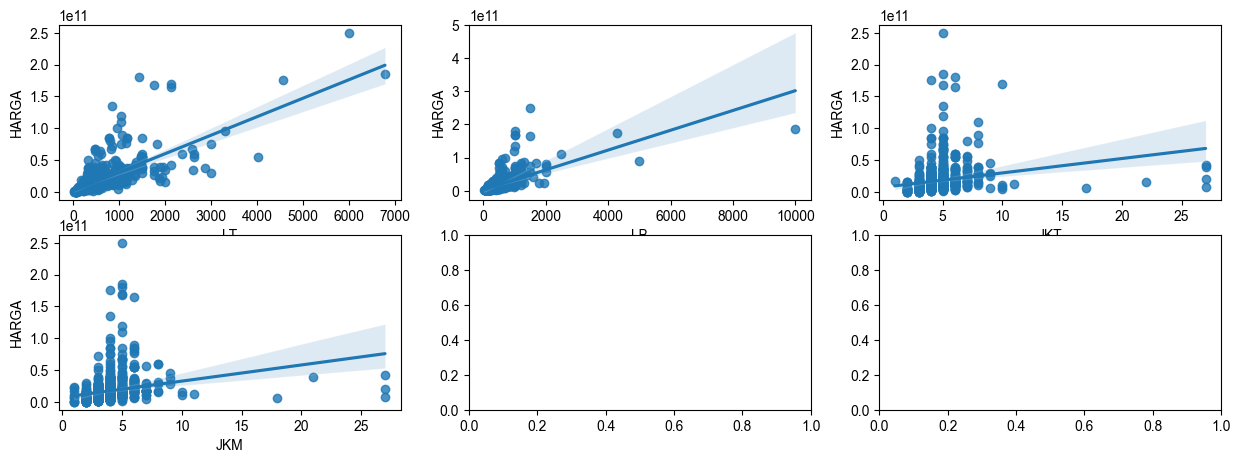

In [6]:
fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(15, 5), dpi=100)
sns.set_style("ticks")
sns.regplot(data=dataset, x="LT", y="HARGA", ax=axs[0][0])
sns.regplot(data=dataset, x="LB", y="HARGA", ax=axs[0][1])
sns.regplot(data=dataset, x="JKT", y="HARGA", ax=axs[0][2])
sns.regplot(data=dataset, x="JKM", y="HARGA", ax=axs[1][0])


In [7]:
data_without_no_and_price = dataset.drop(columns=[], inplace=False)
data_without_no_and_price.describe()

,HARGA,LT,LB,JKT,JKM
count,1.001000e+03,1001.000000,1001.000000,1001.000000,1001.000000
mean,1.747472e+10,530.504496,487.275724,4.457542,3.940060
std,2.079548e+10,531.069773,452.872262,2.004606,1.903261
min,4.300000e+08,22.000000,38.000000,1.000000,1.000000
25%,6.750000e+09,220.000000,300.000000,4.000000,3.000000
50%,1.350000e+10,400.000000,411.000000,4.000000,4.000000
75%,2.000000e+10,677.000000,600.000000,5.000000,4.000000
max,2.500000e+11,6790.000000,10000.000000,27.000000,27.000000


In [8]:
min_price = data_without_no_and_price['HARGA'].min()
max_price = data_without_no_and_price['HARGA'].max()
q = data_without_no_and_price['HARGA'].quantile([.25, .5, .75])
q

0.25    6.750000e+09
0.50    1.350000e+10
0.75    2.000000e+10
Name: HARGA, dtype: float64

In [9]:
def group_by_price_category(price):
    if(price <= q[0.25]):
        return 'Harga Rendah'
    elif(price > q[0.25] and price  <= q[0.50]):
        return 'Harga Menegah'
    elif(price > q[0.50]):
        return 'Harga Tinggi'
    else:
        return '-'

data_with_price_grouping = dataset.copy()
data_with_price_grouping['KELAS HARGA'] = data_with_price_grouping['HARGA'].apply(group_by_price_category)
data_with_price_grouping.head()

,HARGA,LT,LB,JKT,JKM,KOTA,KELAS HARGA
0,1250000000,63,110,3,3,JAKSEL,Harga Rendah
1,28000000000,1100,700,5,6,JAKSEL,Harga Tinggi
2,19000000000,824,800,4,4,JAKSEL,Harga Tinggi
3,4700000000,500,400,4,3,JAKSEL,Harga Rendah
4,4900000000,251,300,5,4,JAKSEL,Harga Rendah


<Axes: xlabel='HARGA', ylabel='LT'>

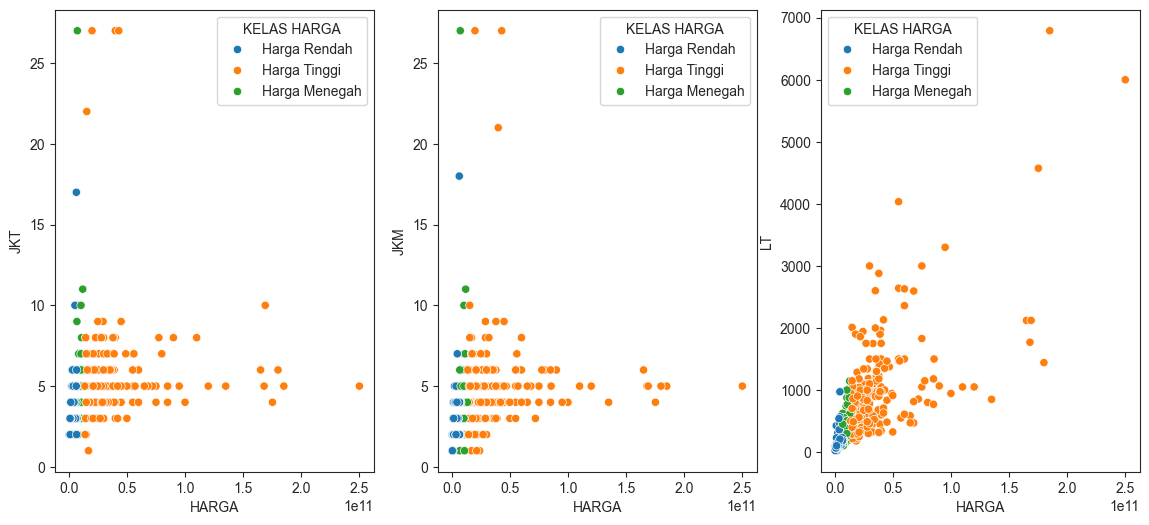

In [10]:


fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(14, 6), dpi=100)
sns.scatterplot(data=data_with_price_grouping, x="HARGA", y="JKT", hue="KELAS HARGA", ax=axs[0])
sns.scatterplot(data=data_with_price_grouping, x="HARGA", y="JKM", hue="KELAS HARGA", ax=axs[1])
sns.scatterplot(data=data_with_price_grouping, x="HARGA", y="LT", hue="KELAS HARGA", ax=axs[2])




In [11]:
prices = dataset['HARGA']
kamar_mandi = dataset["JKM"]
kamar_tidur = dataset["JKT"]
lebar_tanah = dataset["LT"]
lebar_bangunan = dataset["LB"]



In [12]:
rumah_all = []

for i in range(len(kamar_tidur)):
    rumah = []
    rumah.append(kamar_mandi[i])
    rumah.append(kamar_tidur[i])
    rumah.append(lebar_tanah[i])
    rumah.append(lebar_bangunan[i])
    
  

    
    rumah_all.append(rumah)
   

    

In [13]:
print(rumah_all)

rumah_all = np.array(rumah_all)
prices = np.array(prices)


[[3, 3, 63, 110], [6, 5, 1100, 700], [4, 4, 824, 800], [3, 4, 500, 400], [4, 5, 251, 300], [5, 4, 1340, 575], [4, 4, 460, 300], [4, 4, 278, 350], [2, 3, 511, 300], [2, 3, 70, 69], [1, 2, 66, 42], [7, 6, 449, 500], [3, 2, 109, 188], [4, 4, 320, 250], [4, 4, 384, 400], [6, 5, 462, 645], [4, 4, 212, 300], [4, 5, 342, 450], [4, 4, 410, 700], [3, 4, 144, 285], [3, 4, 985, 400], [4, 3, 780, 500], [4, 4, 217, 450], [4, 4, 1500, 700], [3, 4, 210, 300], [3, 3, 110, 200], [4, 4, 760, 650], [3, 3, 151, 245], [3, 4, 220, 350], [3, 3, 128, 315], [3, 3, 235, 270], [3, 4, 100, 250], [5, 5, 470, 1000], [2, 4, 75, 150], [4, 4, 770, 500], [5, 6, 610, 1000], [4, 4, 754, 500], [3, 4, 440, 350], [4, 4, 410, 800], [3, 4, 973, 1100], [4, 4, 251, 320], [4, 4, 780, 600], [3, 4, 954, 600], [5, 6, 1186, 900], [4, 4, 186, 380], [5, 4, 358, 500], [3, 4, 217, 200], [4, 4, 535, 600], [3, 3, 330, 500], [3, 4, 250, 320], [4, 4, 477, 530], [4, 4, 282, 450], [4, 5, 1312, 850], [4, 4, 860, 500], [3, 4, 246, 347], [3, 4, 

In [21]:
model = tf.keras.Sequential([
  tf.keras.layers.Dense(units=1, input_shape=[4]),  

])

In [23]:
model.compile(optimizer='sgd', loss='mae', metrics=['accuracy'])

In [24]:
model.fit(
    rumah_all, prices, epochs=15000
    
)

Epoch 1/15000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 920us/step - accuracy: 0.0000e+00 - loss: 17871507456.0000
Epoch 2/15000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step - accuracy: 0.0000e+00 - loss: 17562226688.0000
Epoch 3/15000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step - accuracy: 0.0000e+00 - loss: 17511237632.0000
Epoch 4/15000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 656us/step - accuracy: 0.0000e+00 - loss: 17576157184.0000
Epoch 5/15000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 663us/step - accuracy: 0.0000e+00 - loss: 16280985600.0000
Epoch 6/15000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 866us/step - accuracy: 0.0000e+00 - loss: 17539096576.0000
Epoch 7/15000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 640us/step - accuracy: 0.0000e+00 - loss: 17815719936.0000
Epoch 8/15000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 657us/step - accuracy: 0.0000e+00 - loss: 17855250432.0000
Epoch 9/15000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 725us/step - accuracy: 0.0000e+00 - loss: 17966802944.0000
Epoch 10/15000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 675us/step - accuracy: 0.000

In [27]:
kmrmndi = int(input("Kamar Mandi? : "))
kmr = int(input("Kamar Tidur? : "))
lt = int(input("Lebar Tanah? : "))
lb = int(input("Lebar Bangunan? : "))


prediksi = model.predict(np.array([[kmrmndi, kmr, lt, lb]]))
harga_prediksi = prediksi[0][0] * 10
print(kmrmndi)
print(kmr)
print(lt)
print(lb)
print("Harga Rumah Yang anda Minta adalah : RP.", int(harga_prediksi))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1
2
33
333
Harga Rumah Yang anda Minta adalah : RP. 8628139520
